In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
import libertem.api as lt
from libertem.udf.raw import PickUDF
from libertem.udf.sum import SumUDF
from libertem.udf import UDF

In [3]:
from scipy.ndimage import shift, center_of_mass
from skimage.transform import downscale_local_mean

In [4]:
import os

In [5]:
%matplotlib widget

In [9]:
work_dir = '/Users/nihy/Desktop/Working Data/CrSBr/ds2'
data_path = '/Users/nihy/Desktop/Working Data/CrSBr/ds2/STEM SI.dm4'
descan_path = '/Users/nihy/Desktop/Working Data/CrSBr/ds3/STEM SI.dm4'

In [18]:
class GetDescan(UDF):
    """
    Get the diffraction pattern shift by calculating the center-of-mass of the central beam within a specified radius.
    """
    def __init__(self, center, radius, *args, **kwargs):
        super().__init__(*args, center = center, radius = radius, **kwargs)

    def get_result_buffers(self):
        return {
            "DPShift": self.buffer(kind = 'nav', dtype = 'float32', extra_shape = (2,))
        }        

    def process_frame(self, frame):
        r00, c00 = self.meta.dataset_shape[2]//2, self.meta.dataset_shape[3]//2
        r0, c0 = self.params.center
        r = self.params.radius

        rr, cc = np.mgrid[0:self.meta.dataset_shape[2], 0:self.meta.dataset_shape[3]]
        mask = (rr - r0)**2 + (cc - c0)**2 <= r**2

        r_com, c_com = (frame*mask*rr).sum()/ (frame*mask).sum(), (frame*mask*cc).sum()/ (frame*mask).sum()
        shift_r, shift_c = r00 - r_com, c00 - c_com
        self.results.DPShift[:] = np.array([shift_r, shift_c])


In [19]:
class ShiftFrame(UDF):
    """
    """

    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)

    def get_result_buffers(self):
        sx, sy = self.meta.dataset_shape[2], self.meta.dataset_shape[3]
        return {
            "shifted_frame": self.buffer(kind = 'nav', 
                                         dtype = self.meta.dataset_dtype,
                                         extra_shape = (sx, sy))
        }

    def process_frame(self, frame):
        s = self.params.aux_data[:]
        sframe = shift(frame, s).astype(frame.dtype)
        self.results.shifted_frame[:] = sframe[:]

# Load Data

In [8]:
ctx =  lt.Context()

In [10]:
ds_descan = ctx.load("dm",descan_path, dataset_index = 3)
ds_descan.shape, ds_descan.dtype

((52, 1000, 128, 128), dtype('uint32'))

In [11]:
ds_data = ctx.load("dm",data_path, dataset_index = 3)
ds_data.shape, ds_data.dtype

((52, 1000, 128, 128), dtype('uint32'))

# Calculate Average Diffraction Pattern

In [12]:
udf = SumUDF()

In [15]:
avgDP = ctx.run_udf(dataset = ds_descan, udf = udf)
avgDP = avgDP["intensity"].data

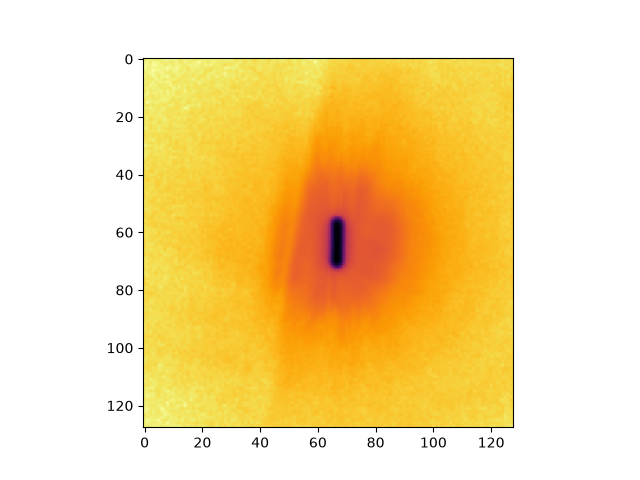

In [16]:
plt.figure()
plt.imshow(avgDP, cmap = "inferno_r", norm = 'log')

# Mesure Descan induced DP shift from frame center

In [21]:
CenteredDS = ctx.run_udf(dataset=ds_descan, udf = GetDescan(center = (64, 64), radius = 15), progress = True)

Partitions 0/15, Frames:   0%|          | 0/52000 [00:00<?, ?it/s]

In [22]:
CenteredDS_data = CenteredDS["DPShift"].data 

In [23]:
aux_data = ShiftFrame.aux_data(
    data = CenteredDS_data,
    kind = 'nav',
    extra_shape = (2,),
    dtype = CenteredDS_data.dtype
)

In [24]:
Centered_DP = ctx.run_udf(dataset = ds_data, udf = ShiftFrame(aux_data = aux_data), progress = True)

Partitions 0/15, Frames:   0%|          | 0/52000 [00:00<?, ?it/s]

/var/folders/ln/_4p49x493sl51gvfsrdld5640000gn/T/ipykernel_11176/4210027707.py:19: RuntimeWarning: invalid value encountered in cast
/var/folders/ln/_4p49x493sl51gvfsrdld5640000gn/T/ipykernel_11176/4210027707.py:19: RuntimeWarning: invalid value encountered in cast
/var/folders/ln/_4p49x493sl51gvfsrdld5640000gn/T/ipykernel_11176/4210027707.py:19: RuntimeWarning: invalid value encountered in cast
/var/folders/ln/_4p49x493sl51gvfsrdld5640000gn/T/ipykernel_11176/4210027707.py:19: RuntimeWarning: invalid value encountered in cast
/var/folders/ln/_4p49x493sl51gvfsrdld5640000gn/T/ipykernel_11176/4210027707.py:19: RuntimeWarning: invalid value encountered in cast
/var/folders/ln/_4p49x493sl51gvfsrdld5640000gn/T/ipykernel_11176/4210027707.py:19: RuntimeWarning: invalid value encountered in cast
/var/folders/ln/_4p49x493sl51gvfsrdld5640000gn/T/ipykernel_11176/4210027707.py:19: RuntimeWarning: invalid value encountered in cast
/var/folders/ln/_4p49x493sl51gvfsrdld5640000gn/T/ipykernel_11176/4210

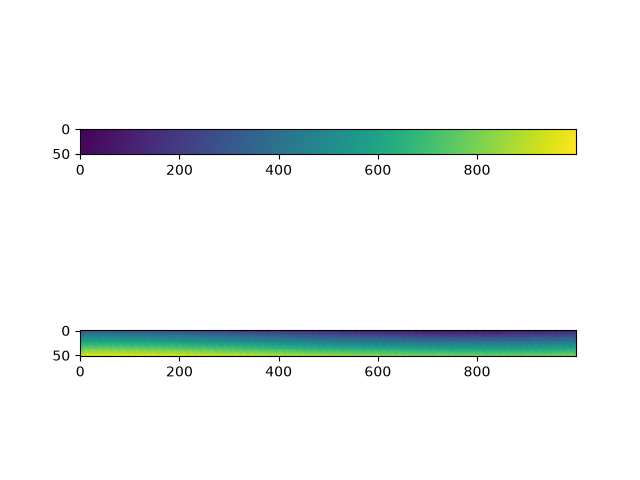

In [25]:
_, axs = plt.subplots(2, 1)
axs[0].imshow(CenteredDS_data[...,0])
axs[1].imshow(CenteredDS_data[...,1])

In [26]:
Centered_DP["shifted_frame"].data.shape

(52, 1000, 128, 128)

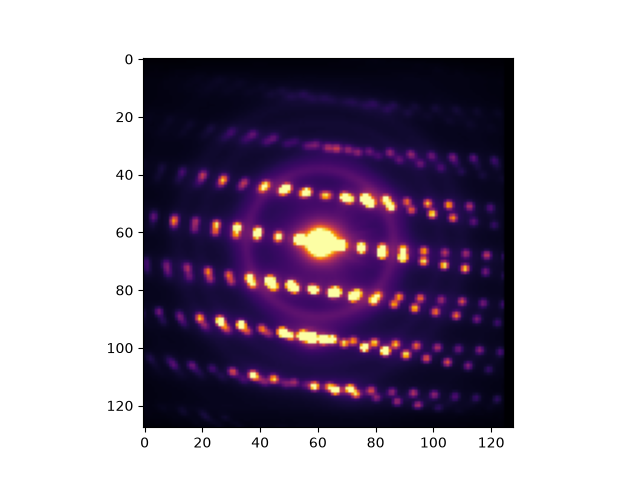

In [31]:
plt.figure()
plt.imshow(Centered_DP["shifted_frame"].data.mean(axis = (0,1)), cmap = "inferno", vmax = 1e4)

# Save Result

In [32]:
np.save(os.path.join(work_dir, "descan_corrected"), Centered_DP["shifted_frame"].data)